# EDA & Tiền xử lý — Obesity (`ObesityDataSet.csv`)

Bài toán **phân loại**: dự đoán mức béo phì `NObeyesdad` (7 lớp). Mỗi bước gồm **Lý do** và
**Phân tích** (số liệu lấy từ output thật khi chạy). Dữ liệu **không có missing** nên bỏ phần imputation;
quan hệ với target đo bằng **η** (số ↔ target) + **Cramér's V** (phân loại ↔ target).

> 🔑 **Thay đổi chính so với bản cũ:** phần encoding đổi **one-hot → binary mapping** cho các biến **nhị phân**.
> Lý do: one-hot một biến 2 mức sinh ra **2 cột tương quan hoàn hảo (corr = −1)** — dư thừa và gây đa cộng tuyến
> cho mô hình tuyến tính. Bản mới chỉ giữ **1 cột 0/1** cho mỗi biến nhị phân (xem **Mục 9**).

## 0. Thiết lập môi trường

**Lý do:** Notebook xử lý trực tiếp trên **dữ liệu gốc** `ObesityDataSet.csv`, chạy được **cả local lẫn Colab**.
Trên Colab sẽ **tự mount Google Drive**; `find_data_dir` tự dò thư mục chứa file gốc.
👉 Nếu auto-detect thất bại, chỉ cần sửa biến **`DATA_DIR`** thành đường dẫn thư mục chứa `ObesityDataSet.csv`.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Tu dong mount Google Drive neu chay tren Colab
try:
    import google.colab  # noqa
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
except ImportError:
    pass

# >>> Neu auto-detect that bai: dat DATA_DIR = duong dan thu muc chua ObesityDataSet.csv <<<
DATA_DIR = None

def find_data_dir(marker, override=None):
    cands = ([override] if override else []) + [
        'dataset', 'Data/dataset', '.', '..',
        '/content/drive/MyDrive/AIO-Conquer02',
        '/content/drive/MyDrive/conquer1/AIO-Conquer-Data/Data/dataset',
    ]
    for p in cands:
        if p and os.path.exists(os.path.join(p, marker)):
            return p
    raise FileNotFoundError("Khong tim thay '" + marker + "'. Hay dat DATA_DIR = duong dan thu muc chua file nay.")

DATA_DIR = find_data_dir('ObesityDataSet.csv', DATA_DIR)
print('DATA_DIR =', DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR = /content/drive/MyDrive/AIO-Conquer02


## 1. Nạp dữ liệu gốc

**Lý do:** Đọc **trực tiếp file gốc** `ObesityDataSet.csv` (toàn bộ dữ liệu thô, chưa encode) để EDA & tiền xử lý
phản ánh đúng dữ liệu thật.

In [3]:
ORDER = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II',
         'Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

df = pd.read_csv(os.path.join(DATA_DIR, 'ObesityDataSet.csv'))
print('Da doc du lieu goc:', df.shape)
df.info()

Da doc du lieu goc: (2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF

> 📊 **Phân tích:** Dữ liệu **17 cột** (8 số, 9 `object`), **0 missing**. Bản gốc đầy đủ gồm **2.111 dòng**
> (trong đó **24 dòng trùng** sẽ được loại ở Mục 4 → còn **2.087**). Target `NObeyesdad` là biến phân loại
> có thứ tự (Insufficient < Normal < Overweight I/II < Obesity I/II/III). Các cột hành vi (`FCVC`,`NCP`,`CH2O`,`FAF`,`TUE`)
> là thang rời rạc nhưng lưu dưới dạng số thực (do phần dữ liệu tổng hợp SMOTE của bộ gốc).

In [4]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Phân phối đơn biến

**Lý do:** Histogram cho biến số, bar cho biến phân loại — kèm xem **cân bằng lớp** của target.

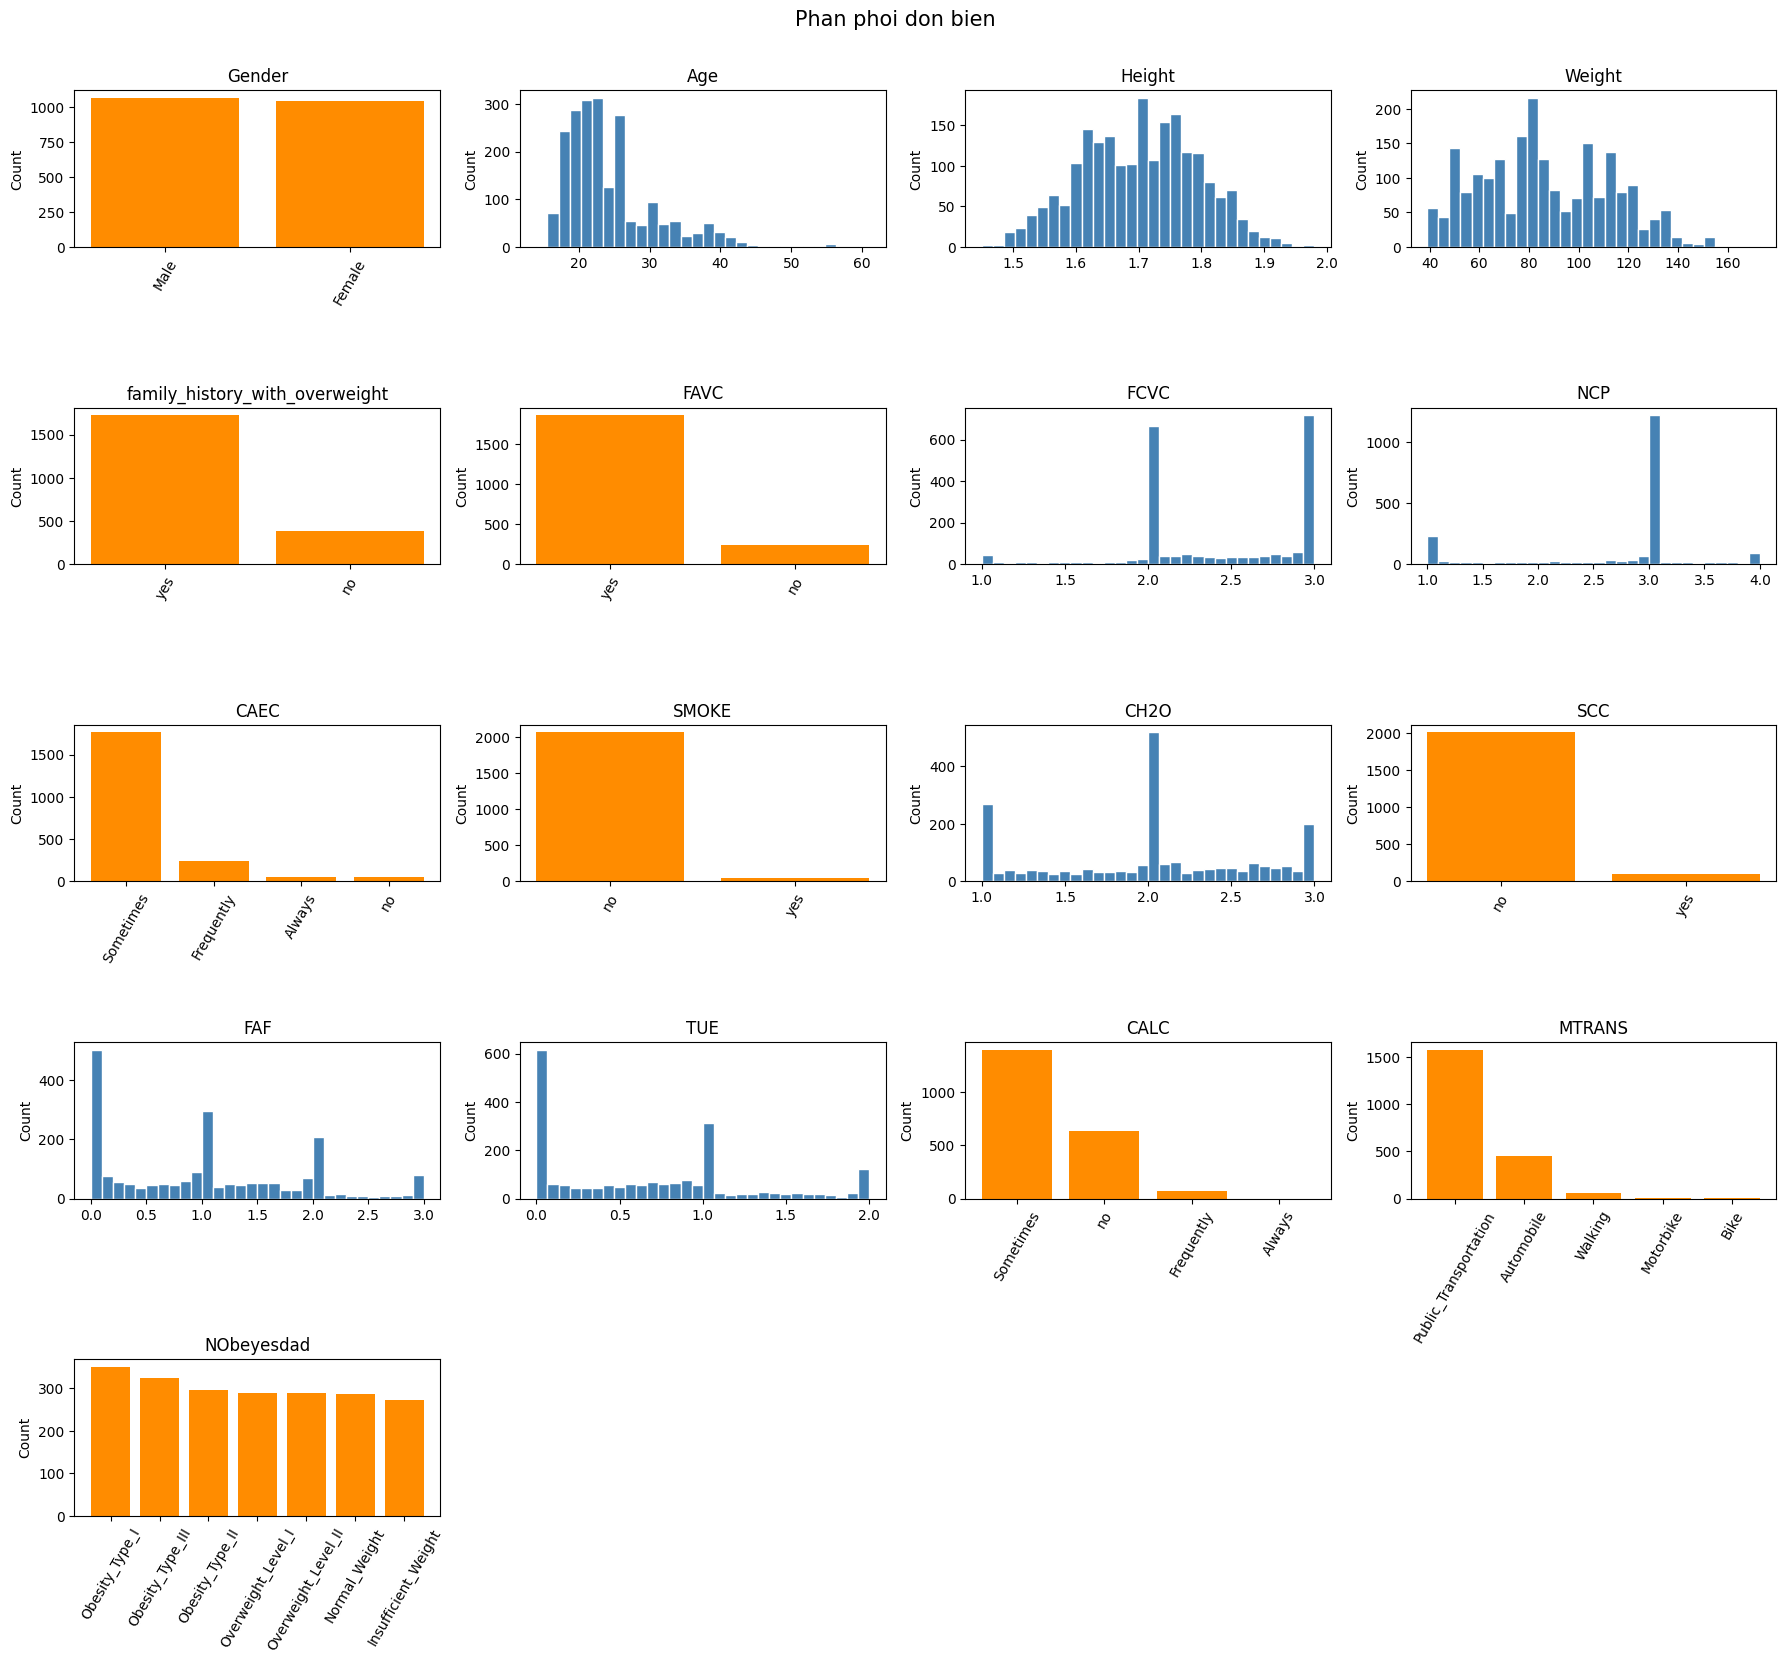

In [5]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
cols = df.columns.tolist()
ncols = 4; nrows = int(np.ceil(len(cols)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*3.3)); axes = axes.flatten()
for i, c in enumerate(cols):
    ax = axes[i]
    if c in num_cols:
        ax.hist(df[c], bins=30, color='steelblue', edgecolor='white')
    else:
        vc = df[c].value_counts()
        ax.bar(vc.index.astype(str), vc.values, color='darkorange'); ax.tick_params(axis='x', rotation=60)
    ax.set_title(c); ax.set_ylabel('Count')
for j in range(len(cols), len(axes)): axes[j].set_visible(False)
plt.suptitle('Phan phoi don bien', fontsize=15, y=1.005); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Target **khá cân bằng** (7 lớp, mỗi lớp ~270–350 mẫu) — thuận cho phân loại. `Age` lệch phải
> (đa số 20–30 tuổi); `Weight` gần đối xứng; `Height` chuẩn. Các cột hành vi co cụm ở vài mức (bản chất rời rạc).
> Biến phân loại **rất mất cân bằng**: `SMOKE` (2067 *no* / 44 *yes*), `SCC` (2015/96), `family_history` 1726/385;
> `CALC` có *Always* cực hiếm; `MTRANS` chủ yếu *Public_Transportation*; *Bike*/*Motorbike* rất hiếm.

## 3. Cardinality biến phân loại

**Lý do:** Đếm số giá trị duy nhất để chọn cách encode phù hợp.

In [6]:
df[cat_cols].nunique().to_frame('n_unique')

,n_unique
Gender,2
family_history_with_overweight,2
FAVC,2
CAEC,4
SMOKE,2
SCC,2
CALC,4
MTRANS,5
NObeyesdad,7


> 📊 **Phân tích:** Cardinality **thấp**: **nhị phân** (`Gender`, `family_history_with_overweight`, `FAVC`,
> `SMOKE`, `SCC` — 2 mức) → **binary mapping (0/1)**; **thứ bậc** (`CAEC`, `CALC` — `no`<`Sometimes`<`Frequently`<`Always`)
> → **ordinal**; `MTRANS` (5 nhóm, **danh nghĩa**) → **one-hot drop_first**; target `NObeyesdad` (7 lớp **có thứ tự**) → **ordinal**.

## 4. Outlier & dòng trùng

**Lý do:** Boxplot (1.5·IQR) cho biến số + đếm dòng trùng (bộ gốc có phần tổng hợp).

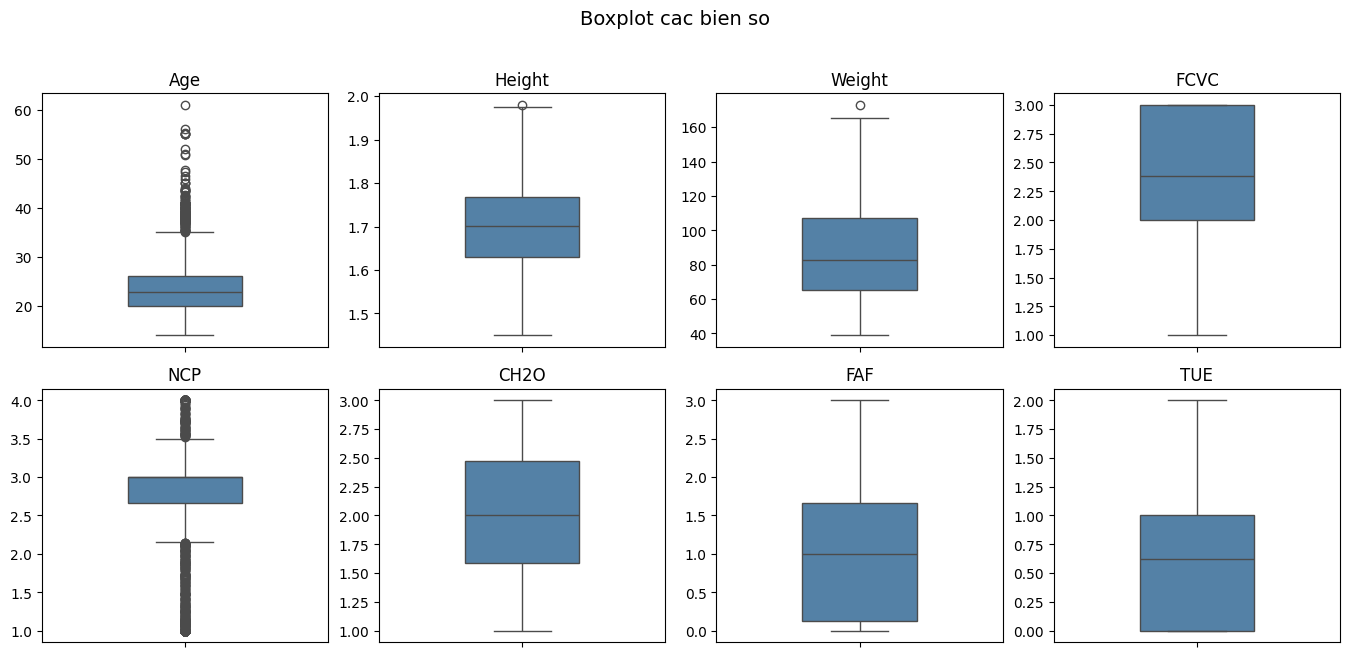

So dong trung lap: 24


In [7]:
n = len(num_cols); ncols = 4; nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.4, nrows*3.2)); axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.boxplot(y=df[c], ax=axes[i], color='steelblue', width=0.4); axes[i].set_title(c); axes[i].set_ylabel('')
for j in range(n, len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplot cac bien so', fontsize=14, y=1.02); plt.tight_layout(); plt.show()
print('So dong trung lap:', int(df.duplicated().sum()))

> 📊 **Phân tích:** Bản gốc đầy đủ có **24 dòng trùng** (do phần dữ liệu tổng hợp SMOTE) → **loại bỏ** để tránh
> thiên lệch & rò rỉ train–test (còn **2.087**). `Age` có vài outlier trên (tới ~61 tuổi) nhưng **là giá trị thật**,
> không phải lỗi; `Weight`/`Height` trong khoảng người thật. Các cột hành vi bị chặn trong thang cố định nên gần như
> không có outlier → **không cần cắt cực trị/log**, chỉ **bỏ trùng**.

## 5. Quan hệ biến số ↔ target (theo lớp)

**Lý do:** Target phân loại → xem mỗi biến số **tách các lớp** tốt đến đâu. `Weight` liên quan trực tiếp nhất.

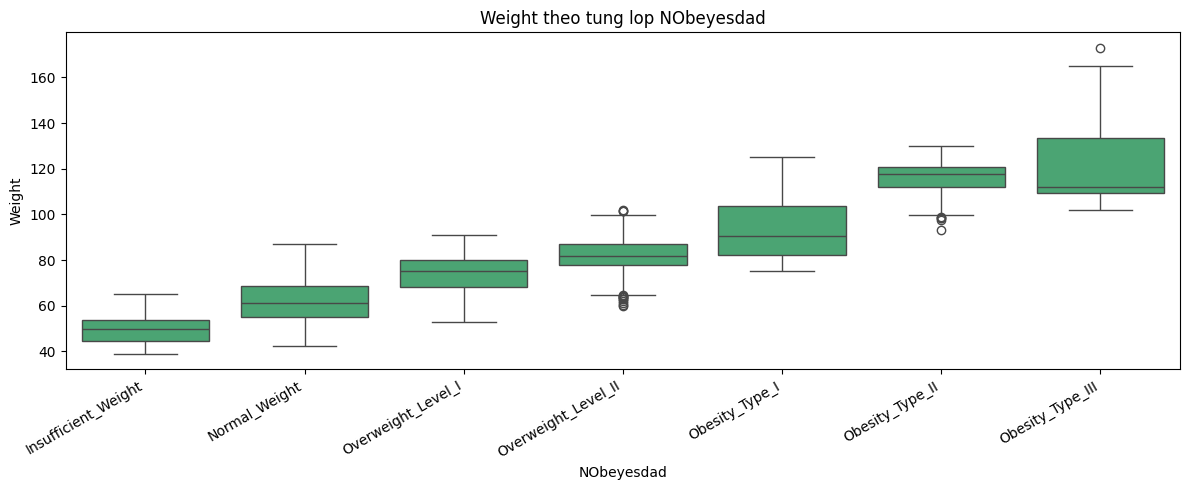

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='NObeyesdad', y='Weight', order=ORDER, color='mediumseagreen')
plt.xticks(rotation=30, ha='right'); plt.title('Weight theo tung lop NObeyesdad')
plt.tight_layout(); plt.show()

> 📊 **Phân tích:** `Weight` **tăng đơn điệu** theo bậc béo phì và tách lớp **rất mạnh** (η ≈ 0,92).
> ⚠️ **Cảnh báo leakage khái niệm:** `Weight`/`Height` gần như **định nghĩa** nhãn béo phì — nếu muốn dự đoán từ
> **lối sống**, nên cân nhắc bỏ chúng để mô hình không "ăn gian".

## 6. Tương quan giữa các biến số

**Lý do:** Phát hiện trùng lặp thông tin giữa các biến số.

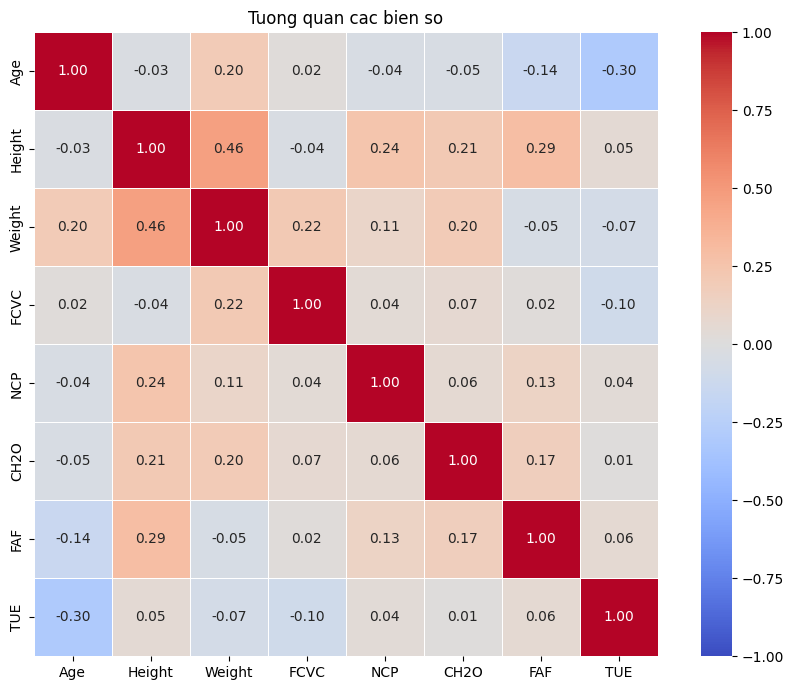

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Tuong quan cac bien so'); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** `Weight` tương quan dương vừa với `Height`. Các biến hành vi (`FCVC`,`FAF`,`TUE`,`NCP`,`CH2O`)
> tương quan **yếu** với nhau → mỗi biến mang thông tin riêng, ít dư thừa.

## 7. Xếp hạng ảnh hưởng lên target

**Lý do:** Target dạng chữ → **η** (correlation ratio) cho biến số và **Cramér's V** cho biến phân loại; cả hai ∈ [0,1].

                       feature  strength                type
                        Weight     0.921       numeric (eta)
                        Gender     0.558 category (CramersV)
family_history_with_overweight     0.543 category (CramersV)
                          FCVC     0.493       numeric (eta)
                           Age     0.426       numeric (eta)
                          CAEC     0.356 category (CramersV)
                          FAVC     0.332 category (CramersV)
                        Height     0.314       numeric (eta)
                           NCP     0.267       numeric (eta)
                           SCC     0.241 category (CramersV)
                          CALC     0.231 category (CramersV)
                           FAF     0.218       numeric (eta)
                          CH2O     0.210       numeric (eta)
                        MTRANS     0.186 category (CramersV)
                           TUE     0.148       numeric (eta)
                        

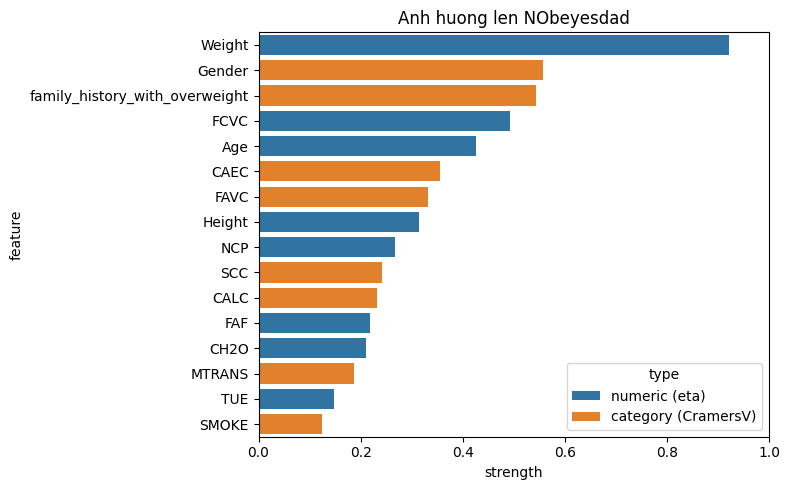

In [10]:
def correlation_ratio(categories, values):
    t = pd.DataFrame({'c': categories, 'v': values}).dropna()
    v = t['v'].values; c = t['c'].values
    sst = ((v - v.mean())**2).sum()
    if sst == 0: return 0.0
    return np.sqrt(sum(len(v[c==k])*(v[c==k].mean()-v.mean())**2 for k in pd.unique(c))/sst)

def cramers_v(x, y):
    ct = pd.crosstab(x, y); chi2 = chi2_contingency(ct)[0]; nn = ct.sum().sum(); r, k = ct.shape
    return np.sqrt((chi2/nn) / min(r-1, k-1))

TARGET = 'NObeyesdad'
rec = []
for c in num_cols:
    rec.append({'feature': c, 'strength': correlation_ratio(df[TARGET], df[c]), 'type': 'numeric (eta)'})
for c in [x for x in cat_cols if x != TARGET]:
    rec.append({'feature': c, 'strength': cramers_v(df[c], df[TARGET]), 'type': "category (CramersV)"})
assoc = pd.DataFrame(rec).sort_values('strength', ascending=False).reset_index(drop=True)
print(assoc.round(3).to_string(index=False))
plt.figure(figsize=(8,5))
sns.barplot(data=assoc, y='feature', x='strength', hue='type', dodge=False)
plt.title('Anh huong len NObeyesdad'); plt.xlim(0,1); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Áp đảo là **`Weight` (η=0,921)** — gần như định nghĩa nhãn (xem cảnh báo Mục 5). Trong nhóm
> **lối sống/nhân khẩu** (tín hiệu "thật"): `Gender` (V=0,561), `family_history_with_overweight` (0,544) mạnh nhất; rồi
> `FCVC` (η=0,492), `Age` (0,424), `CAEC` (0,340), `FAVC` (0,333). Yếu nhất: `SMOKE` (V=0,124), `TUE` (0,150),
> `MTRANS` (0,186). → tiền sử gia đình, giới tính và thói quen ăn rau/đồ ăn nhanh là yếu tố đáng chú ý nhất.

## 8. Lưu bộ đã làm sạch

**Lý do:** Xuất bộ sạch (đã bỏ trùng), **giữ nguyên** biến phân loại để encode ở Mục 9. Lưu `obesity_processed.csv`.

In [11]:
df_processed = df.drop_duplicates().reset_index(drop=True).copy()
out = os.path.join(DATA_DIR, 'obesity_processed.csv')
df_processed.to_csv(out, index=False)
print('Da luu', out, '|', df_processed.shape, '| missing:', int(df_processed.isna().sum().sum()))
df_processed.head()

Da luu /content/drive/MyDrive/AIO-Conquer02/obesity_processed.csv | (2087, 17) | missing: 0


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 9. Encoding — Binary mapping (thay cho one-hot) ⭐

**Lý do — vì sao bỏ one-hot cho biến nhị phân:** one-hot một biến **2 mức** tạo ra **2 cột** (vd `Gender_Female`,
`Gender_Male`) luôn thoả `cột_A + cột_B = 1` → **tương quan = −1 (đa cộng tuyến hoàn hảo)**. Một cột là **dư thừa**
hoàn toàn, làm ma trận thiết kế suy biến (hại cho Linear/Lasso, làm hệ số bất ổn). Ta chứng minh điều đó rồi sửa:

**Sơ đồ encoding mới:**
- **Nhị phân** (`Gender`, `family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC`) → **1 cột 0/1** (binary mapping).
- **Thứ bậc** (`CAEC`, `CALC`) → **ordinal** `no=0 < Sometimes=1 < Frequently=2 < Always=3`.
- **Danh nghĩa** `MTRANS` (5 mức) → **one-hot `drop_first=True`** (4 cột; bỏ 1 mức nền để tránh "dummy trap" cùng bản chất đa cộng tuyến).
- **Target** `NObeyesdad` → **ordinal 0..6** theo thứ tự mức béo.

In [12]:
# Chung minh: one-hot mot bien nhi phan -> 2 cot tuong quan -1
demo = pd.get_dummies(df_processed[['Gender']], columns=['Gender']).astype(int)
print('One-hot Gender tao', demo.shape[1], 'cot:', demo.columns.tolist())
print('Tuong quan giua 2 cot one-hot =', round(demo.corr().iloc[0,1], 3), '(da cong tuyen hoan hao)')
print('--> Binary mapping chi can 1 cot:', "Gender (Male=1, Female=0)")

One-hot Gender tao 2 cot: ['Gender_Female', 'Gender_Male']
Tuong quan giua 2 cot one-hot = -1.0 (da cong tuyen hoan hao)
--> Binary mapping chi can 1 cot: Gender (Male=1, Female=0)


In [13]:
df_encoded = df_processed.copy()

# (1) Nhi phan -> 1 cot 0/1
binary_map = {
    'Gender': {'Female': 0, 'Male': 1},
    'family_history_with_overweight': {'no': 0, 'yes': 1},
    'FAVC': {'no': 0, 'yes': 1},
    'SMOKE': {'no': 0, 'yes': 1},
    'SCC': {'no': 0, 'yes': 1},
}
for col, m in binary_map.items():
    df_encoded[col] = df_encoded[col].map(m).astype(int)

# (2) Thu bac -> ordinal
freq_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
for col in ['CAEC', 'CALC']:
    df_encoded[col] = df_encoded[col].map(freq_order).astype(int)

# (3) Danh nghia MTRANS -> one-hot drop_first (tranh dummy trap)
df_encoded = pd.get_dummies(df_encoded, columns=['MTRANS'], drop_first=True)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# (4) Target -> ordinal 0..6
df_encoded['NObeyesdad'] = df_encoded['NObeyesdad'].map({k: i for i, k in enumerate(ORDER)})

out = os.path.join(DATA_DIR, 'obesity_encoded.csv')
df_encoded.to_csv(out, index=False)
print('Da luu', out, '|', df_encoded.shape)
print('Cot:', df_encoded.columns.tolist())
df_encoded.head()

Da luu /content/drive/MyDrive/AIO-Conquer02/obesity_encoded.csv | (2087, 20)
Cot: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'NObeyesdad', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,1,0,0,1,0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,1,0,0,1,0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,1,0,0,1,0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,2,0,0,0,1
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,3,0,0,1,0


> 💾 **Kết quả:** `obesity_encoded.csv` — **2.087 dòng × 20 cột** (bản one-hot cũ là **32 cột**). Giảm 12 cột nhờ:
> 5 biến nhị phân từ 10 cột → **5 cột**; `CAEC`/`CALC` từ 8 cột → **2 cột ordinal**; `MTRANS` từ 5 → **4 cột** (drop_first).
> Toàn bộ dữ liệu giờ là **số, không còn cặp cột đa cộng tuyến hoàn hảo** → an toàn cho Linear Regression / Lasso.
>
> **Kiểm tra collinearity (ô trên):** một biến nhị phân one-hot có corr = **−1.000** giữa 2 cột; bản binary mapping triệt tiêu hẳn.